# Training a simple CNN model in `keras` (>3.0) for Tornado Detection

This notebook steps through how to train a simple CNN model using a subset of TorNet.

This will not produce a model with any skill, but simply provides a working end-to-end example of how to set up a data loader, build, and fit a model

In this run, our data will include values from the CWOP dataset


In [70]:
import os
os.environ['KERAS_BACKEND']='tensorflow' # set to 'tensorflow', 'torch' or 'jax' (installs required)

In [71]:
import sys
# Uncomment if tornet isn't installed in your environment or in your path already
sys.path.append('../')

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras

from tornet.data.tf.loader import create_tf_dataset 
from tornet.data.constants import MAIDS_VARIABLES
from tornet.data.constants import ALL_VARIABLES


In [72]:
# keras accepts most data loaders (tensorflow, torch).
# A pure keras data loader, with necessary preprocessing steps for the cnn baseline, is provided
from tornet.data.keras.loader import KerasDataLoader
data_root = "/Users/evanshabsove/Documents/georgian/summer_2025/AIDI-1004/assignment-2/tornet/tornet_data"
ds = KerasDataLoader(data_root=data_root,
                     data_type='train',
                     years=[2013],
                     batch_size = 128,
                     workers = 4,
                     use_multiprocessing = True,
                     use_madis_data = True)


madis_min_max: [[9.0000e+04 1.1000e+05]
 [0.0000e+00 3.6000e+02]
 [0.0000e+00 5.0000e+01]
 [0.0000e+00 5.0000e+01]
 [0.0000e+00 1.0000e+02]
 [2.3315e+02 3.2315e+02]
 [2.3315e+02 3.2315e+02]]


Model: "TornadoDetectorWithMadis"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ DBZ (InputLayer)    │ (None, 120, 240,  │          0 │ -                 │
│                     │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ VEL (InputLayer)    │ (None, 120, 240,  │          0 │ -                 │
│                     │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ KDP (InputLayer)    │ (None, 120, 240,  │          0 │ -                 │
│                     │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ RHOHV (InputLayer)  │ (None, 120, 240,  │          0 │ -                 │
│                     │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ZDR (InputLayer)    │ (None, 120, 240,  │          0 │ -                 │
│                     │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ WIDTH (InputLayer)  │ (None, 120, 240,  │          0 │ -                 │
│                     │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Normalized_DBZ      │ (None, 120, 240,  │          0 │ DBZ[0][0]         │
│ (Normalization)     │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Normalized_VEL      │ (None, 120, 240,  │          0 │ VEL[0][0]         │
│ (Normalization)     │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Normalized_KDP      │ (None, 120, 240,  │          0 │ KDP[0][0]         │
│ (Normalization)     │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Normalized_RHOHV    │ (None, 120, 240,  │          0 │ RHOHV[0][0]       │
│ (Normalization)     │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Normalized_ZDR      │ (None, 120, 240,  │          0 │ ZDR[0][0]         │
│ (Normalization)     │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Normalized_WIDTH    │ (None, 120, 240,  │          0 │ WIDTH[0][0]       │
│ (Normalization)     │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Concatenate1        │ (None, 120, 240,  │          0 │ Normalized_DBZ[0… │
│ (Concatenate)       │ 12)               │            │ Normalized_VEL[0… │
│                     │                   │            │ Normalized_KDP[0… │
│                     │                   │            │ Normalized_RHOHV… │
│                     │                   │            │ Normalized_ZDR[0… │
│                     │                   │            │ Normalized_WIDTH… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ isnan_7 (Isnan)     │ (None, 120, 240,  │          0 │ Concatenate1[0][… │
│                     │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ where_7 (Where)     │ (None, 120, 240,  │          0 │ isnan_7[0][0],    │
│                     │ 12)               │            │ Concatenate1[0][… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 3,795 (14.82 KB)

 Trainable params: 3,795 (14.82 KB)

 Non-trainable params: 0 (0.00 B)

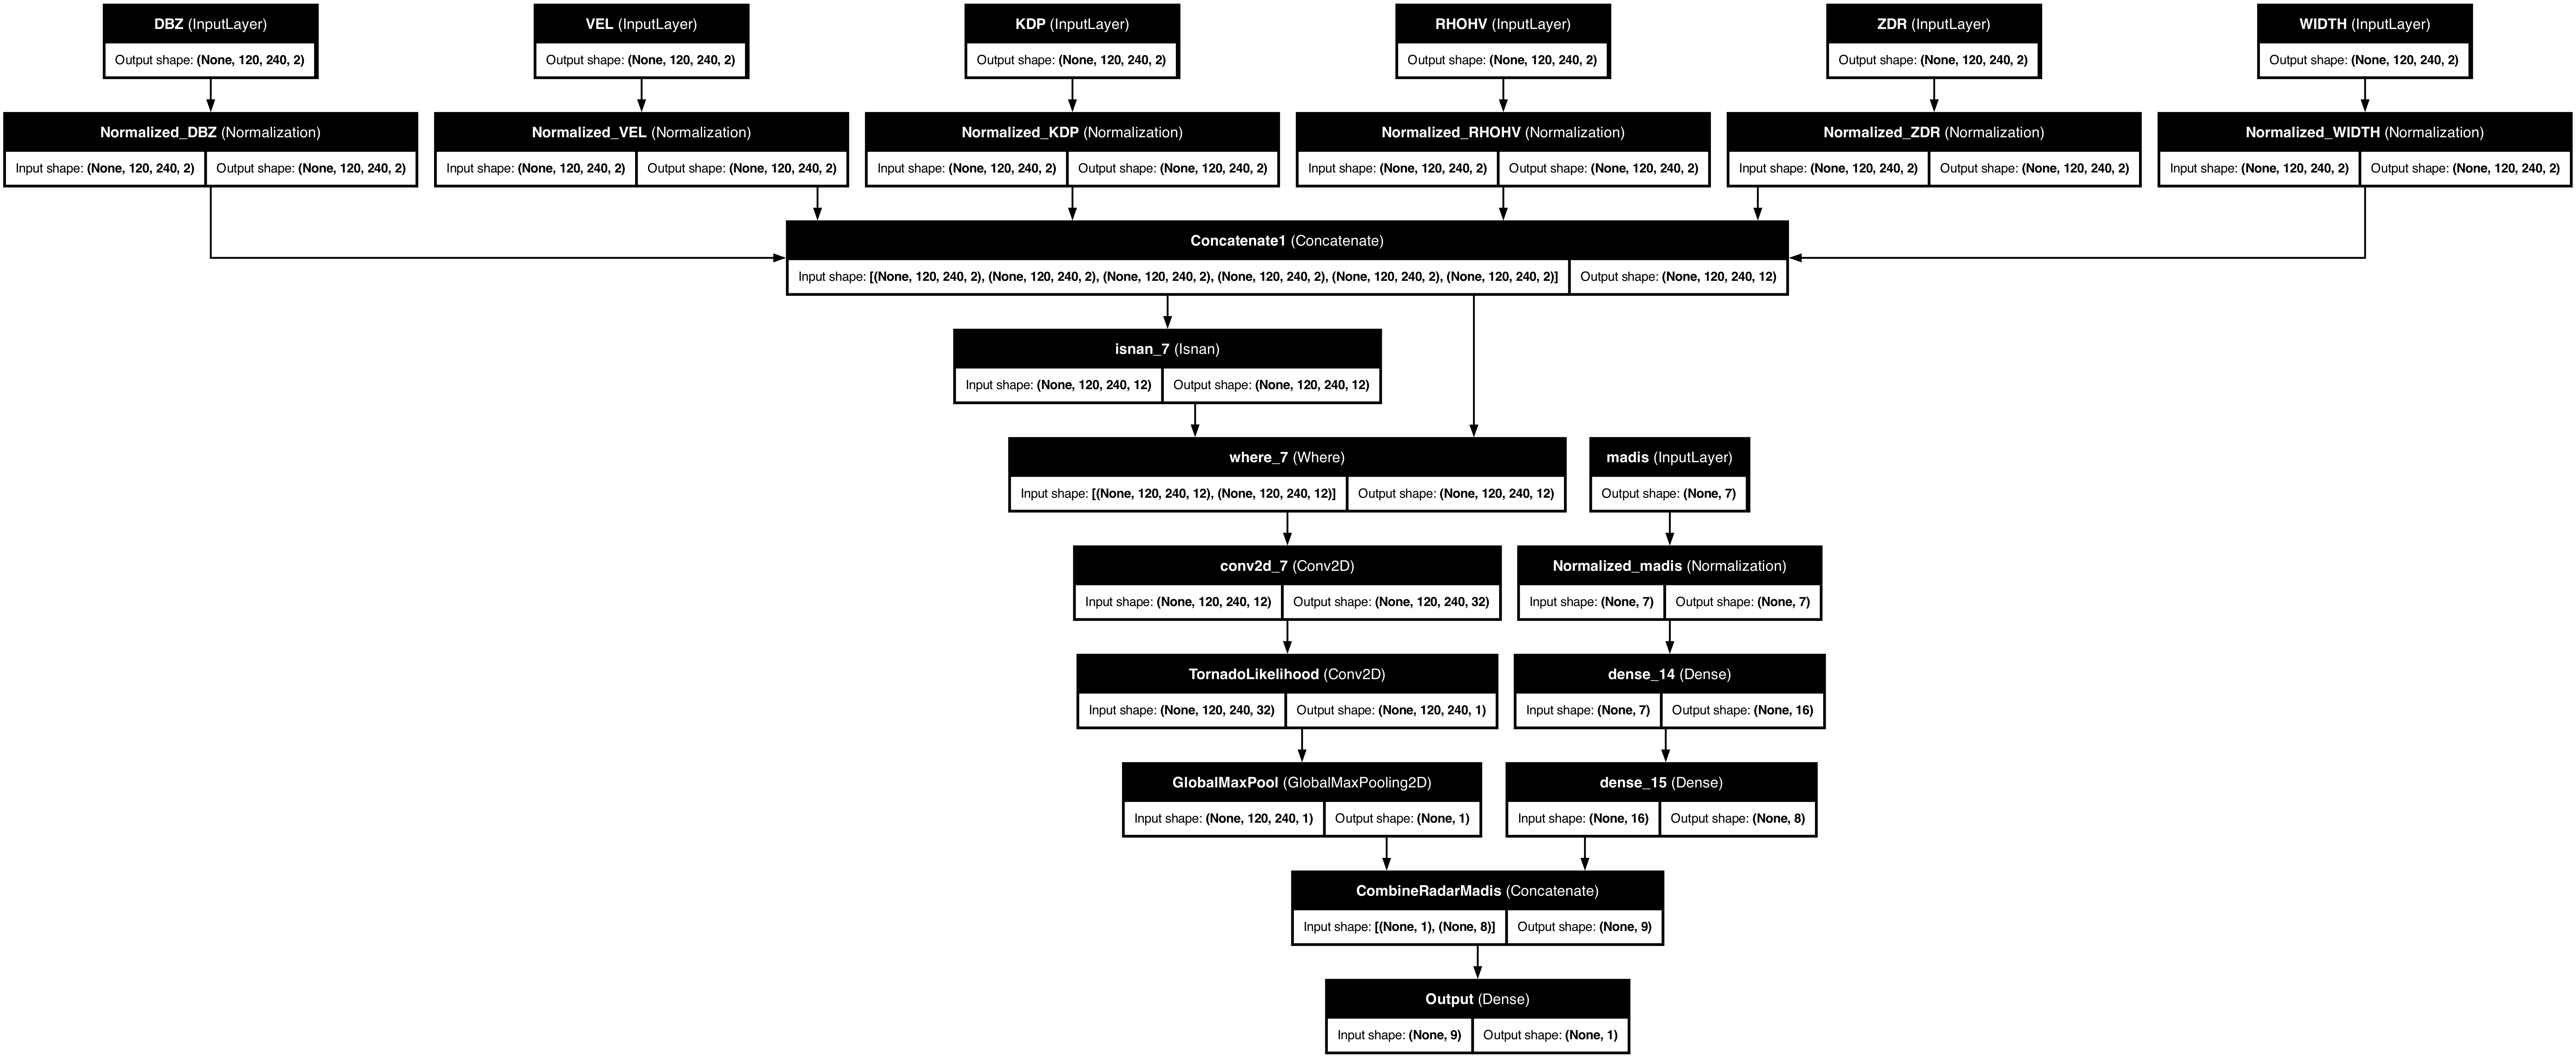

In [73]:
# Create a simple CNN model
# This normalizes data, concatenates along channel, and applies a Conv2D
from tornet.data.constants import CHANNEL_MIN_MAX
from tornet.data.constants import MADIS_MIN_MAX
from tornet.models.keras.layers import FillNaNs
from keras.utils import plot_model
from keras.layers import Lambda

input_vars = ALL_VARIABLES # which variables to use

# TF convention is B,L,W,H
inputs = {v:keras.Input(shape=(120,240,2),name=v) for v in input_vars}

# MADIS variables are added to the input
madis_input = keras.Input(shape=(len(MAIDS_VARIABLES),), name="madis")

# Normalize inputs
norm_layers = []
for v in input_vars:
    min_max = np.array(CHANNEL_MIN_MAX[v]) # [2,]

    # choose mean,var to get approximate [-1,1] scaling
    var=((min_max[1]-min_max[0])/2)**2 # scalar
    var=np.array(2*[var,])    # [n_sweeps,]
    offset=(min_max[0]+min_max[1])/2    # scalar
    offset=np.array(2*[offset,]) # [n_sweeps,]
    
    norm_layers.append(
        keras.layers.Normalization(mean=offset, variance=var,
                                   name='Normalized_%s' % v)
    )

# --- MADIS normalization ---
madis_min_max = np.array(MADIS_MIN_MAX)  # shape: (num_madis_vars, 2)
print(f"madis_min_max: {madis_min_max}")  # Debugging line to check MADIS min-max values
madis_mean = (madis_min_max[:, 0] + madis_min_max[:, 1]) / 2
madis_var = ((madis_min_max[:, 1] - madis_min_max[:, 0]) / 2) ** 2

madis_norm = keras.layers.Normalization(mean=madis_mean, variance=madis_var, name='Normalized_madis')
madis_x = madis_norm(madis_input)

# Concatenate normed inputs along channel dimension
x=keras.layers.Concatenate(axis=-1,name='Concatenate1')(
        [l(inputs[v]) for l,v in zip(norm_layers,input_vars)]
        )

# Replace background (nan) with -3
x = FillNaNs(fill_val=-3,name='ReplaceNan')(x)

# Processing
x = keras.layers.Conv2D(32,3,padding='same',activation='relu')(x)
# add more..
x = keras.layers.Conv2D(1,1,padding='same',activation='relu',name='TornadoLikelihood')(x)
# y = keras.layers.GlobalMaxPool2D(name='GlobalMaxPool')(x)
x = keras.layers.GlobalMaxPool2D(name='GlobalMaxPool')(x)


# Optionally process MADIS input (e.g., dense layers)
madis_x = keras.layers.Dense(16, activation='relu')(madis_x)
madis_x = keras.layers.Dense(8, activation='relu')(madis_x)

# Scale MADIS input to reduce its influence
# madis_x = Lambda(lambda t: t * 0.01, name='ScaleMadis')(madis_x)  # Try 0.1, or 0.01 for even less influence

# Concatenate radar and MADIS features
combined = keras.layers.Concatenate(name='CombineRadarMadis')([x, madis_x])

# Final output
output = keras.layers.Dense(1, activation='sigmoid', name='Output')(combined)

model = keras.Model(inputs=[*inputs.values(), madis_input], outputs=output, name='TornadoDetectorWithMadis')
model.summary()

plot_model(model, show_shapes=True, show_layer_names=True, to_file='model_architecture.png')
# model = keras.Model(inputs=inputs,outputs=y,name='TornadoDetector')

# model.summary()

In [74]:
# Compile
import tornet.metrics.keras.metrics as km

opt  = keras.optimizers.Adam(learning_rate=1e-3)
loss=keras.losses.BinaryCrossentropy(from_logits=True)
metrics = [
    keras.metrics.AUC(from_logits=True, name='AUC'),
    km.BinaryAccuracy(from_logits=True, name='BinaryAccuracy'),
    keras.metrics.Precision(name='Precision'),
    keras.metrics.Recall(name='Recall')
]
model.compile(loss=loss, optimizer=opt, metrics=metrics)

In [ ]:
# Train
# steps_per_epoch=10 for demo purposes
history = model.fit(ds,epochs=25)

Epoch 1/25


/opt/anaconda3/lib/python3.12/site-packages/keras/src/backend/tensorflow/nn.py:789: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Sigmoid activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - AUC: 0.5793 - BinaryAccuracy: 0.0889 - Precision: 0.0889 - Recall: 1.0000 - loss: 1.0834
Epoch 2/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - AUC: 0.5396 - BinaryAccuracy: 0.0889 - Precision: 0.0889 - Recall: 1.0000 - loss: 0.9614
Epoch 3/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - AUC: 0.5579 - BinaryAccuracy: 0.0889 - Precision: 0.0889 - Recall: 1.0000 - loss: 0.8723
Epoch 4/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - AUC: 0.6677 - BinaryAccuracy: 0.0889 - Precision: 0.0930 - Recall: 1.0000 - loss: 0.8088
Epoch 5/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - AUC: 0.6860 - BinaryAccuracy: 0.0889 - Precision: 0.0976 - Recall: 1.0000 - loss: 0.7674
Epoch 6/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - AUC: 0.6799 - BinaryAccuracy: 0.0889 - Precision: 0.1000 - Recall: 1.0000 - loss: 0.7432
Epoch 7/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - AUC: 0.6616 - BinaryAccuracy: 0.0889 - Precision: 0.1000 - Recall: 1.0000 - loss: 0.7293
Epoch 8/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s

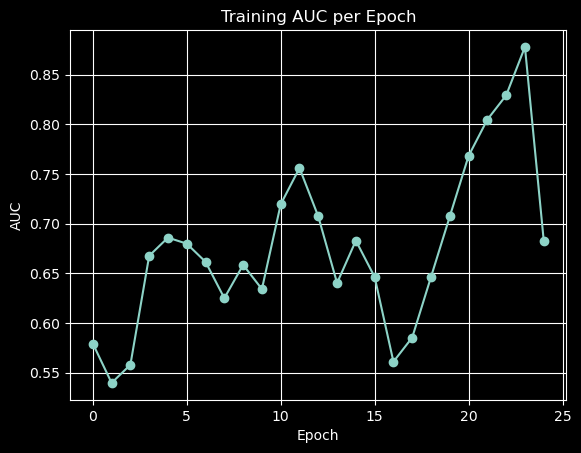

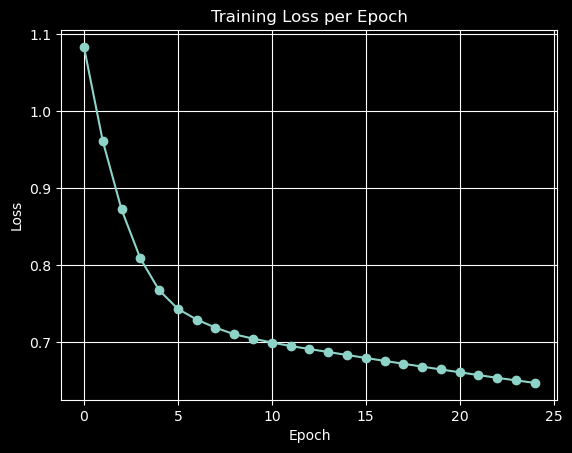

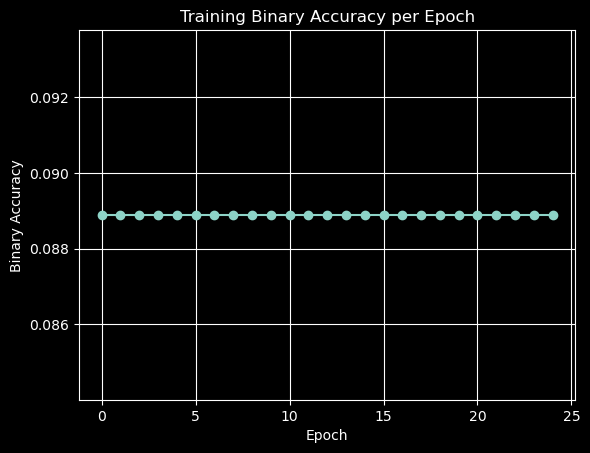

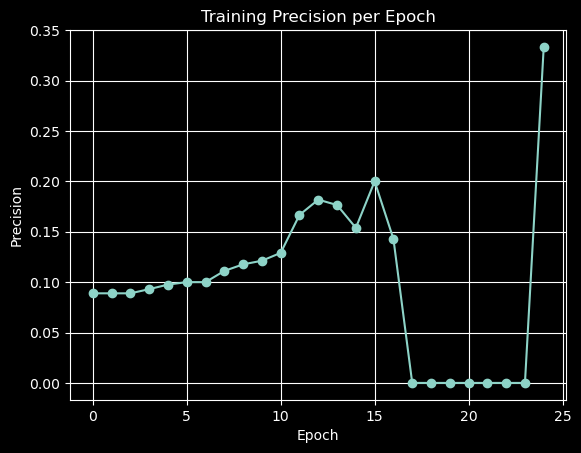

In [76]:
# Graphing AUC for each epoch
import matplotlib.pyplot as plt

# Plot AUC for each epoch
plt.plot(history.history['AUC'], marker='o')
plt.title('Training AUC per Epoch')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.grid(True)
plt.show()

plt.plot(history.history['loss'], marker='o')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()


plt.plot(history.history['BinaryAccuracy'], marker='o')
plt.title('Training Binary Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Binary Accuracy')
plt.grid(True)
plt.show()


plt.plot(history.history['Precision'], marker='o')
plt.title('Training Precision per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.grid(True)
plt.show()


In [77]:
# Build a test set
ds_test = KerasDataLoader(data_root=data_root,
                         data_type='test',
                         years=[2013],
                         batch_size = 128,
                         workers = 4,
                         use_multiprocessing = True,
                         use_madis_data = True)


In [78]:
# Evaluate

metrics = [keras.metrics.AUC(from_logits=True,name='AUC'),
           km.BinaryAccuracy(from_logits=True,name='BinaryAccuracy'),
           keras.metrics.Precision(name='Precision'),
           keras.metrics.Recall(name='Recall')
           ]
model.compile(loss=loss,metrics=metrics)

# steps=10 for demo purposes
model.evaluate(ds_test,steps=10)


/opt/anaconda3/lib/python3.12/site-packages/keras/src/backend/tensorflow/nn.py:789: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Sigmoid activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - AUC: 0.3200 - BinaryAccuracy: 0.2857 - Precision: 0.1429 - Recall: 0.1000 - loss: 0.6895


/opt/anaconda3/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


[0.6895493865013123,
 0.3199999928474426,
 0.2857142984867096,
 0.1428571492433548,
 0.10000000149011612]

In [79]:
# Scan all MADIS XML files and print min/max for each variable in a table
# import glob
# import xml.etree.ElementTree as ET
# from collections import defaultdict
# import numpy as np

# madis_dir = '/Users/evanshabsove/Documents/georgian/summer_2025/AIDI-1004/assignment-2/tornet/tornet_data/madis_data'
# var_minmax = defaultdict(lambda: [np.inf, -np.inf])

# # print(f'Scanning MADIS XML files in {madis_dir}...')
# for fname in glob.glob(f'{madis_dir}/*.xml'):
#     # print(f'Processing {fname}...')
#     try:
#         tree = ET.parse(fname)
#         root = tree.getroot()
#         for rec in root.findall('record'):
#             var = rec.attrib.get('var')
#             val = rec.attrib.get('data_value')
#             if var is not None and val is not None:
#                 try:
#                     val = float(val)
#                     if val < var_minmax[var][0]:
#                         var_minmax[var][0] = val
#                     if val > var_minmax[var][1]:
#                         var_minmax[var][1] = val
#                 except ValueError:
#                     continue
#     except Exception as e:
#         print(f'Error parsing {fname}: {e}')

# # Print results in a table
# print(f"{'Variable':<15} {'Min':>15} {'Max':>15}")
# print('-'*45)
# for var in sorted(var_minmax.keys()):
#     vmin, vmax = var_minmax[var]
#     print(f"{var:<15} {vmin:>15.6f} {vmax:>15.6f}")